In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marianelabaez/electronics-store-sales")

print("Path to dataset files:", path)

c:\Users\kriti\anaconda3\envs\KRITIKAKASPAL_ENV\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\kriti\.cache\kagglehub\datasets\marianelabaez\electronics-store-sales\versions\1


In [10]:
# Number of rows
n = 200

electronics_data = {

    "Transaction_ID": np.arange(1, n + 1),

    "Store": np.random.choice(
        ["Store_A", "Store_B", "Store_C"],
        n
    ),

    "City": np.random.choice(
        ["London", "Tokyo", "Paris", "New York"],
        n
    ),

    "Product": np.random.choice(
        ["Laptop", "Smartphone", "TV", "Tablet", "Camera"],
        n
    ),

    "Category": np.random.choice(
        ["Electronics"],
        n
    ),

    "Quarter": np.random.choice(
        ["Q1", "Q2", "Q3", "Q4"],
        n
    ),

    "Quantity": np.random.randint(1, 6, n),

    "Price": np.random.randint(500, 5000, n)
}

print("Dataset Created Successfully")

Dataset Created Successfully


In [3]:
import pandas as pd
import numpy as np
import json
import os
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("[SYSTEM] Environment ready. All libraries imported.")

[SYSTEM] Environment ready. All libraries imported.


In [9]:
df = pd.DataFrame(electronics_data)

# Create Sales Column
df["Sales"] = df["Quantity"] * df["Price"]

df.head(10)

,Transaction_ID,Store,City,Product,Category,Quarter,Quantity,Price,Sales
0,1,Store_A,Tokyo,Camera,Electronics,Q1,5,4770,23850
1,2,Store_C,London,Laptop,Electronics,Q3,4,3310,13240
2,3,Store_A,Tokyo,Tablet,Electronics,Q4,1,3592,3592
3,4,Store_B,London,Laptop,Electronics,Q1,3,3544,10632
4,5,Store_C,New York,Laptop,Electronics,Q1,5,4014,20070
5,6,Store_C,London,Tablet,Electronics,Q3,1,2298,2298
6,7,Store_A,Tokyo,Smartphone,Electronics,Q4,4,3075,12300
7,8,Store_A,New York,Smartphone,Electronics,Q4,3,644,1932
8,9,Store_B,Tokyo,Camera,Electronics,Q2,3,4426,13278
9,10,Store_C,New York,TV,Electronics,Q2,3,1877,5631


In [12]:
import os

os.makedirs("data_lake", exist_ok=True)

print("Folder ready")

Folder ready


In [13]:
import pandas as pd
import numpy as np

n = 200

df = pd.DataFrame({
    "Transaction_ID": np.arange(1, n+1),
    "City": np.random.choice(["London", "Tokyo", "Paris", "New York"], n),
    "Product": np.random.choice(["Laptop", "TV", "Phone"], n),
    "Quantity": np.random.randint(1, 5, n),
    "Price": np.random.randint(500, 3000, n)
})

df["Sales"] = df["Quantity"] * df["Price"]

print("Dataset created")

Dataset created


In [14]:
df.to_csv("data_lake/electronics_store_sales.csv", index=False)

print("File saved inside data_lake folder")

File saved inside data_lake folder


In [15]:
df = pd.read_csv("data_lake/electronics_store_sales.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Transaction_ID  200 non-null    int64
 1   City            200 non-null    str  
 2   Product         200 non-null    str  
 3   Quantity        200 non-null    int64
 4   Price           200 non-null    int64
 5   Sales           200 non-null    int64
dtypes: int64(4), str(2)
memory usage: 9.5 KB


In [17]:
df = pd.read_csv("data_lake/electronics_store_sales.csv")

df.describe()

,Transaction_ID,Quantity,Price,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,2.530000,1743.555000,4471.310000
std,57.879185,1.133811,637.816775,2714.114897
min,1.000000,1.000000,507.000000,561.000000
25%,50.750000,2.000000,1288.250000,2060.000000
50%,100.500000,3.000000,1761.000000,4092.500000
75%,150.250000,4.000000,2244.250000,6346.500000
max,200.000000,4.000000,2973.000000,11688.000000


In [18]:
df = pd.read_csv("data_lake/electronics_store_sales.csv")

df.columns

Index(['Transaction_ID', 'City', 'Product', 'Quantity', 'Price', 'Sales'], dtype='str')

In [26]:
import numpy as np

df["Quarter"] = np.random.choice(["Q1", "Q2", "Q3", "Q4"], len(df))

df.head()

,Transaction_ID,City,Product,Quantity,Price,Sales,Quarter
0,1,London,TV,4,1847,7388,Q3
1,2,Tokyo,Phone,4,1357,5428,Q2
2,3,Tokyo,Laptop,4,1655,6620,Q4
3,4,London,Laptop,4,2532,10128,Q2
4,5,Paris,TV,3,1020,3060,Q1


In [29]:
import numpy as np

df["season"] = np.random.choice(
    ["Q1", "Q2", "Q3", "Q4"],
    len(df)
)

df.head()

,Transaction_ID,City,Product,Quantity,Price,Sales,Quarter,season
0,1,London,TV,4,1847,7388,Q3,Q4
1,2,Tokyo,Phone,4,1357,5428,Q2,Q4
2,3,Tokyo,Laptop,4,1655,6620,Q4,Q4
3,4,London,Laptop,4,2532,10128,Q2,Q1
4,5,Paris,TV,3,1020,3060,Q1,Q2


In [30]:
q1_sales = df[df["season"] == "Q1"]
q1_sales.head()

,Transaction_ID,City,Product,Quantity,Price,Sales,Quarter,season
3,4,London,Laptop,4,2532,10128,Q2,Q1
16,17,Paris,Phone,4,2243,8972,Q1,Q1
23,24,Paris,Laptop,3,975,2925,Q1,Q1
24,25,Tokyo,TV,2,1789,3578,Q2,Q1
35,36,London,TV,3,1819,5457,Q4,Q1


In [32]:
tv_sales = df[df["Product"] == "TV"]

tv_sales.head()

,Transaction_ID,City,Product,Quantity,Price,Sales,Quarter,season
0,1,London,TV,4,1847,7388,Q3,Q4
4,5,Paris,TV,3,1020,3060,Q1,Q2
9,10,London,TV,1,2058,2058,Q3,Q4
13,14,Paris,TV,4,2339,9356,Q3,Q4
18,19,London,TV,3,1588,4764,Q2,Q3


In [34]:
import numpy as np

df["season"] = np.random.choice(["Q1", "Q2", "Q3", "Q4"], len(df))

In [37]:
dice = df[
    (df["season"] == "Q1") &
    (df["Product"] == "TV") &
    (df["City"] == "London")
]

dice.head()

,Transaction_ID,City,Product,Quantity,Price,Sales,Quarter,season
35,36,London,TV,3,1819,5457,Q4,Q1
46,47,London,TV,4,1909,7636,Q1,Q1
53,54,London,TV,1,2712,2712,Q2,Q1
79,80,London,TV,3,2112,6336,Q2,Q1


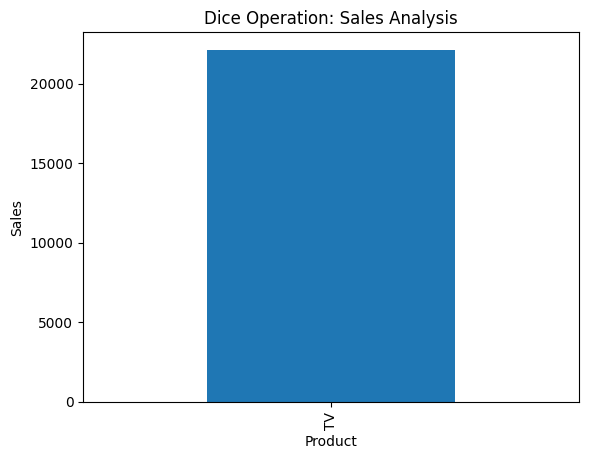

In [43]:
import matplotlib.pyplot as plt

dice.groupby("Product")["Sales"].sum().plot(kind="bar")

plt.title("Dice Operation: Sales Analysis")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

In [44]:
import numpy as np

df["store"] = np.random.choice(["Store_A", "Store_B", "Store_C"], len(df))
df["season"] = np.random.choice(["Q1", "Q2", "Q3", "Q4"], len(df))

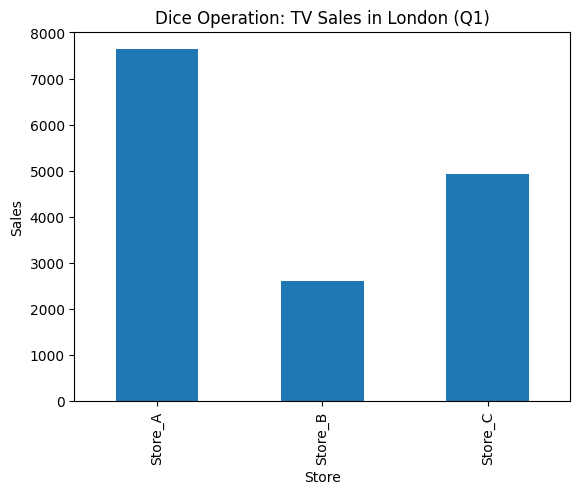

In [45]:
dice = df[
    (df["season"] == "Q1") &
    (df["Product"] == "TV") &
    (df["City"] == "London")
]

dice.groupby("store")["Sales"].sum().plot(kind="bar")

plt.title("Dice Operation: TV Sales in London (Q1)")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()

In [47]:
drill = df.groupby(['City', 'Product'])['Sales'].sum().reset_index()

drill

,City,Product,Sales
0,London,Laptop,96459
1,London,Phone,84794
2,London,TV,94520
3,New York,Laptop,97278
4,New York,Phone,74894
5,New York,TV,56491
6,Paris,Laptop,64604
7,Paris,Phone,40062
8,Paris,TV,57849
9,Tokyo,Laptop,48646


In [51]:
df.columns

Index(['Transaction_ID', 'City', 'Product', 'Quantity', 'Price', 'Sales',
       'Quarter', 'season', 'store'],
      dtype='str')

In [52]:
import numpy as np

df["store"] = np.random.choice(["Store_A", "Store_B", "Store_C"], len(df))

In [53]:
drill_down = df.groupby(['City', 'store'])['Sales'].sum().reset_index()

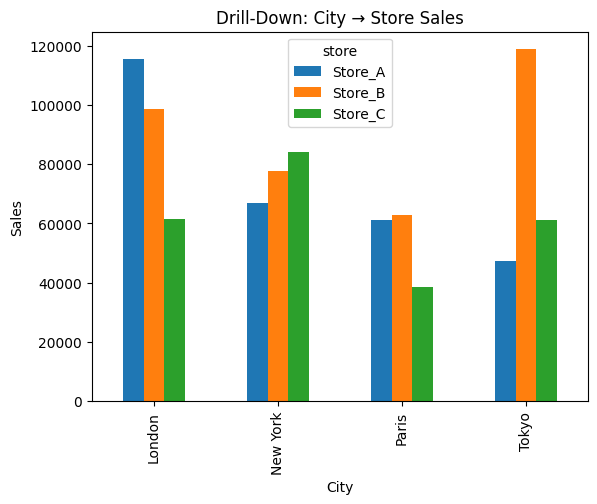

In [56]:
import matplotlib.pyplot as plt

drill_down.groupby(['City', 'store'])['Sales'].sum().unstack().plot(kind='bar')

plt.title("Drill-Down: City → Store Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.show()

In [58]:
rollup = df.groupby('season')['Sales'].sum().reset_index()

rollup

,season,Sales
0,Q1,249230
1,Q2,210467
2,Q3,236056
3,Q4,198509


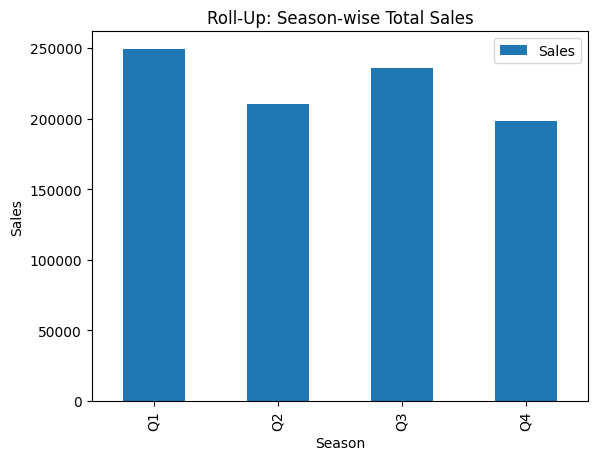

In [60]:
import matplotlib.pyplot as plt

rollup.plot(x='season', y='Sales', kind='bar')

plt.title("Roll-Up: Season-wise Total Sales")
plt.xlabel("Season")
plt.ylabel("Sales")
plt.show()

In [62]:
product_sales = df.groupby('Product')['Sales'].sum().reset_index()

product_sales

,Product,Sales
0,Laptop,306987
1,Phone,328445
2,TV,258830


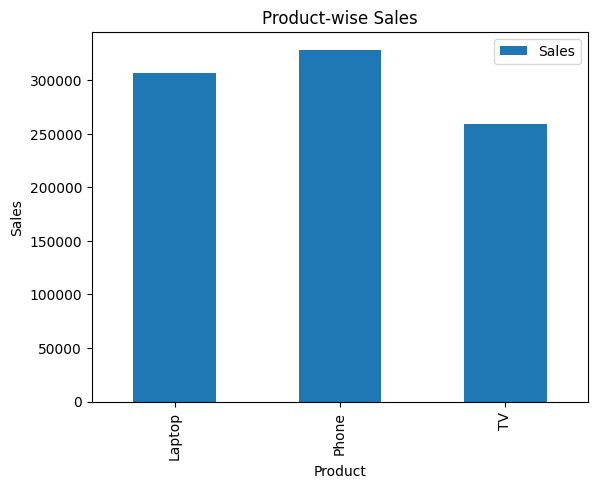

In [64]:
import matplotlib.pyplot as plt

product_sales.plot(x='Product', y='Sales', kind='bar')

plt.title("Product-wise Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

In [65]:
cube = pd.pivot_table(
    df,
    values='Sales',
    index='City',
    columns='Product',
    aggfunc='sum'
)

cube

Product,Laptop,Phone,TV
City,,,
London,96459,84794,94520
New York,97278,74894,56491
Paris,64604,40062,57849
Tokyo,48646,128695,49970


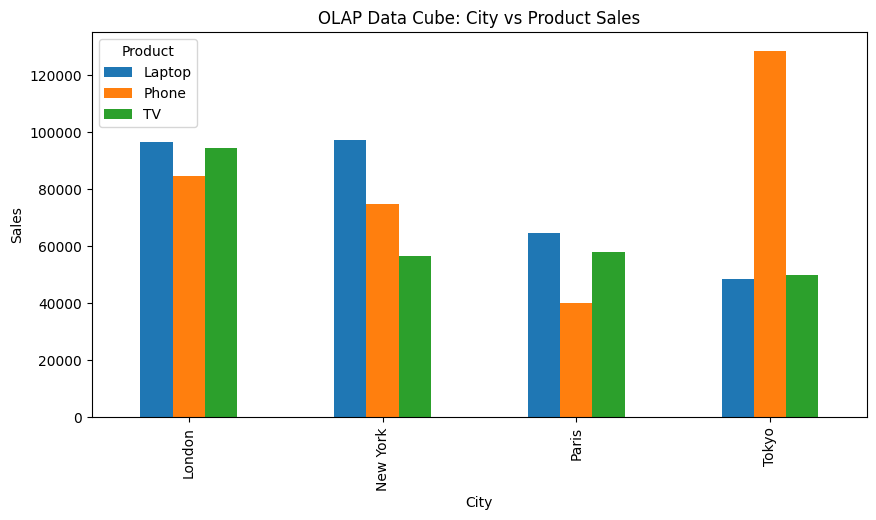

In [66]:
import matplotlib.pyplot as plt

cube.plot(kind='bar', figsize=(10,5))

plt.title("OLAP Data Cube: City vs Product Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.show()

In [67]:
slice_q1 = df[df['season'] == 'Q1']

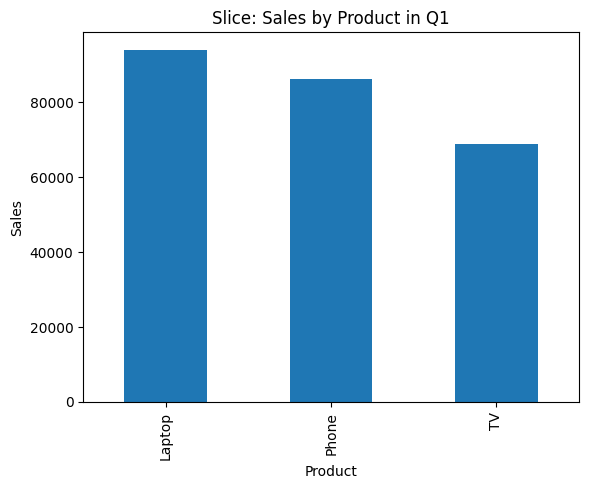

In [69]:
import matplotlib.pyplot as plt

slice_q1.groupby('Product')['Sales'].sum().plot(kind='bar')

plt.title("Slice: Sales by Product in Q1")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

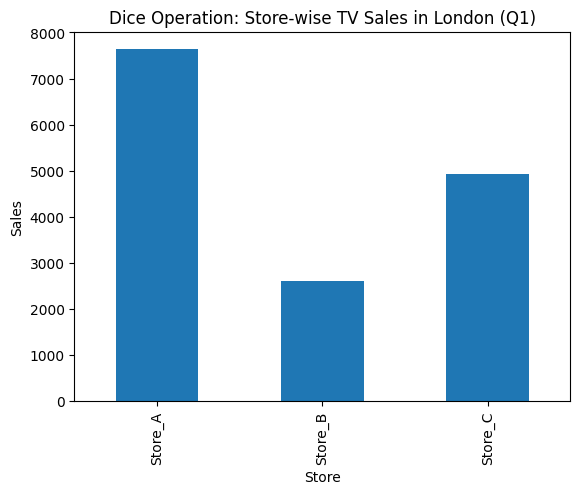

In [72]:
dice.groupby('store')['Sales'].sum().plot(kind='bar')

plt.title("Dice Operation: Store-wise TV Sales in London (Q1)")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()

In [73]:
fact_table = df[[
    "Transaction_ID",
    "City",
    "Product",
    "Quantity",
    "Price",
    "Sales"
]]

print("Fact Table:")
print(fact_table.head())

Fact Table:
   Transaction_ID    City Product  Quantity  Price  Sales
0               1  London      TV         4   1847   7388
1               2   Tokyo   Phone         4   1357   5428
2               3   Tokyo  Laptop         4   1655   6620
3               4  London  Laptop         4   2532  10128
4               5   Paris      TV         3   1020   3060


In [74]:
dim_city = df[["City"]].drop_duplicates()

dim_product = df[["Product"]].drop_duplicates()

print("City Dimension:")
print(dim_city.head())

print("\nProduct Dimension:")
print(dim_product.head())

City Dimension:
       City
0    London
1     Tokyo
4     Paris
6  New York

Product Dimension:
  Product
0      TV
1   Phone
2  Laptop


In [75]:
fact_sales = df.copy()

fact_returns = df.sample(50).copy()
fact_returns["return_amount"] = fact_returns["Sales"] * 0.1

print("Sales Fact Table:", fact_sales.shape)
print("Returns Fact Table:", fact_returns.shape)

Sales Fact Table: (200, 9)
Returns Fact Table: (50, 10)


In [77]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Correct features from your dataset
features = df[["Quantity", "Price", "Sales"]]

# Standardize data
scaled = StandardScaler().fit_transform(features)

# PCA reduction
pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled)

print("Original shape:", features.shape)
print("Reduced shape:", reduced.shape)

Original shape: (200, 3)
Reduced shape: (200, 2)
